## Instalar dependencias

In [3]:
!pip install -q imbalanced-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

## Descargar datasets

In [4]:
import pandas as pd

df = pd.read_csv('/content/employee_promotion_prediction.csv')
print(df.head())

   employee_id  age  gender education_level marital_status city_tier  \
0            1   50  Female          Master        Married     Tier1   
1            2   36    Male        Bachelor        Married     Tier1   
2            3   29  Female        Bachelor        Married     Tier2   
3            4   42    Male        Bachelor        Married     Tier1   
4            5   40  Female          Master        Married     Tier1   

    department employment_type  years_at_company  years_in_current_role  ...  \
0      Finance       Full-time                10                      4  ...   
1        Sales       Full-time                 9                      5  ...   
2  Engineering       Full-time                 7                      5  ...   
3   Operations       Full-time                 4                      4  ...   
4   Operations       Full-time                 2                      2  ...   

          salary  salary_increase_percent  bonus_last_year  stock_options  \
0  137633

## Exploracion de los datos

En este caso no existen columnas vacias por lo que no hay necesidad de elimanar instacias o hacer una imputación a los datos

In [5]:
print(df.info())
print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nDistribución de la variable objetivo:")
print(df['promoted'].value_counts())
print("\nDistribución porcentual:")
print(df['promoted'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29853 entries, 0 to 29852
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 29853 non-null  int64  
 1   age                         29853 non-null  int64  
 2   gender                      29853 non-null  object 
 3   education_level             29853 non-null  object 
 4   marital_status              29853 non-null  object 
 5   city_tier                   29853 non-null  object 
 6   department                  29853 non-null  object 
 7   employment_type             29853 non-null  object 
 8   years_at_company            29853 non-null  int64  
 9   years_in_current_role       29853 non-null  int64  
 10  years_since_last_promotion  29853 non-null  int64  
 11  team_size                   29853 non-null  int64  
 12  performance_score           29853 non-null  float64
 13  performance_last_year       298

Usando una matiz de correlación podemos ver que hay ciertas variables que no afectan a casi nada a la variable promoted



* team_size ≈ 0.0005
* remote_work_ratio ≈ -0.0004
* deadline_adherence_rate ≈ 0.0011
* cross_department_projects ≈ 0.0045
* mentoring_sessions ≈ 0.0011
* internal_mobility_score ≈ 0.0029
* attendance_rate ≈ 0.0079
* training_hours_last_year ≈ 0.0103
* certifications_count ≈ 0.0113



Tambien hay variables que representan factores muy similares como:


* performance_score con performance_last_year ≈ 0.918
* performance_score con performance_two_years_ago ≈ 0.761
* performance_last_year con performance_two_years_ago ≈ 0.828





Por lo que nos quedaremos solo con uno, en este caso:

* performance_last_year

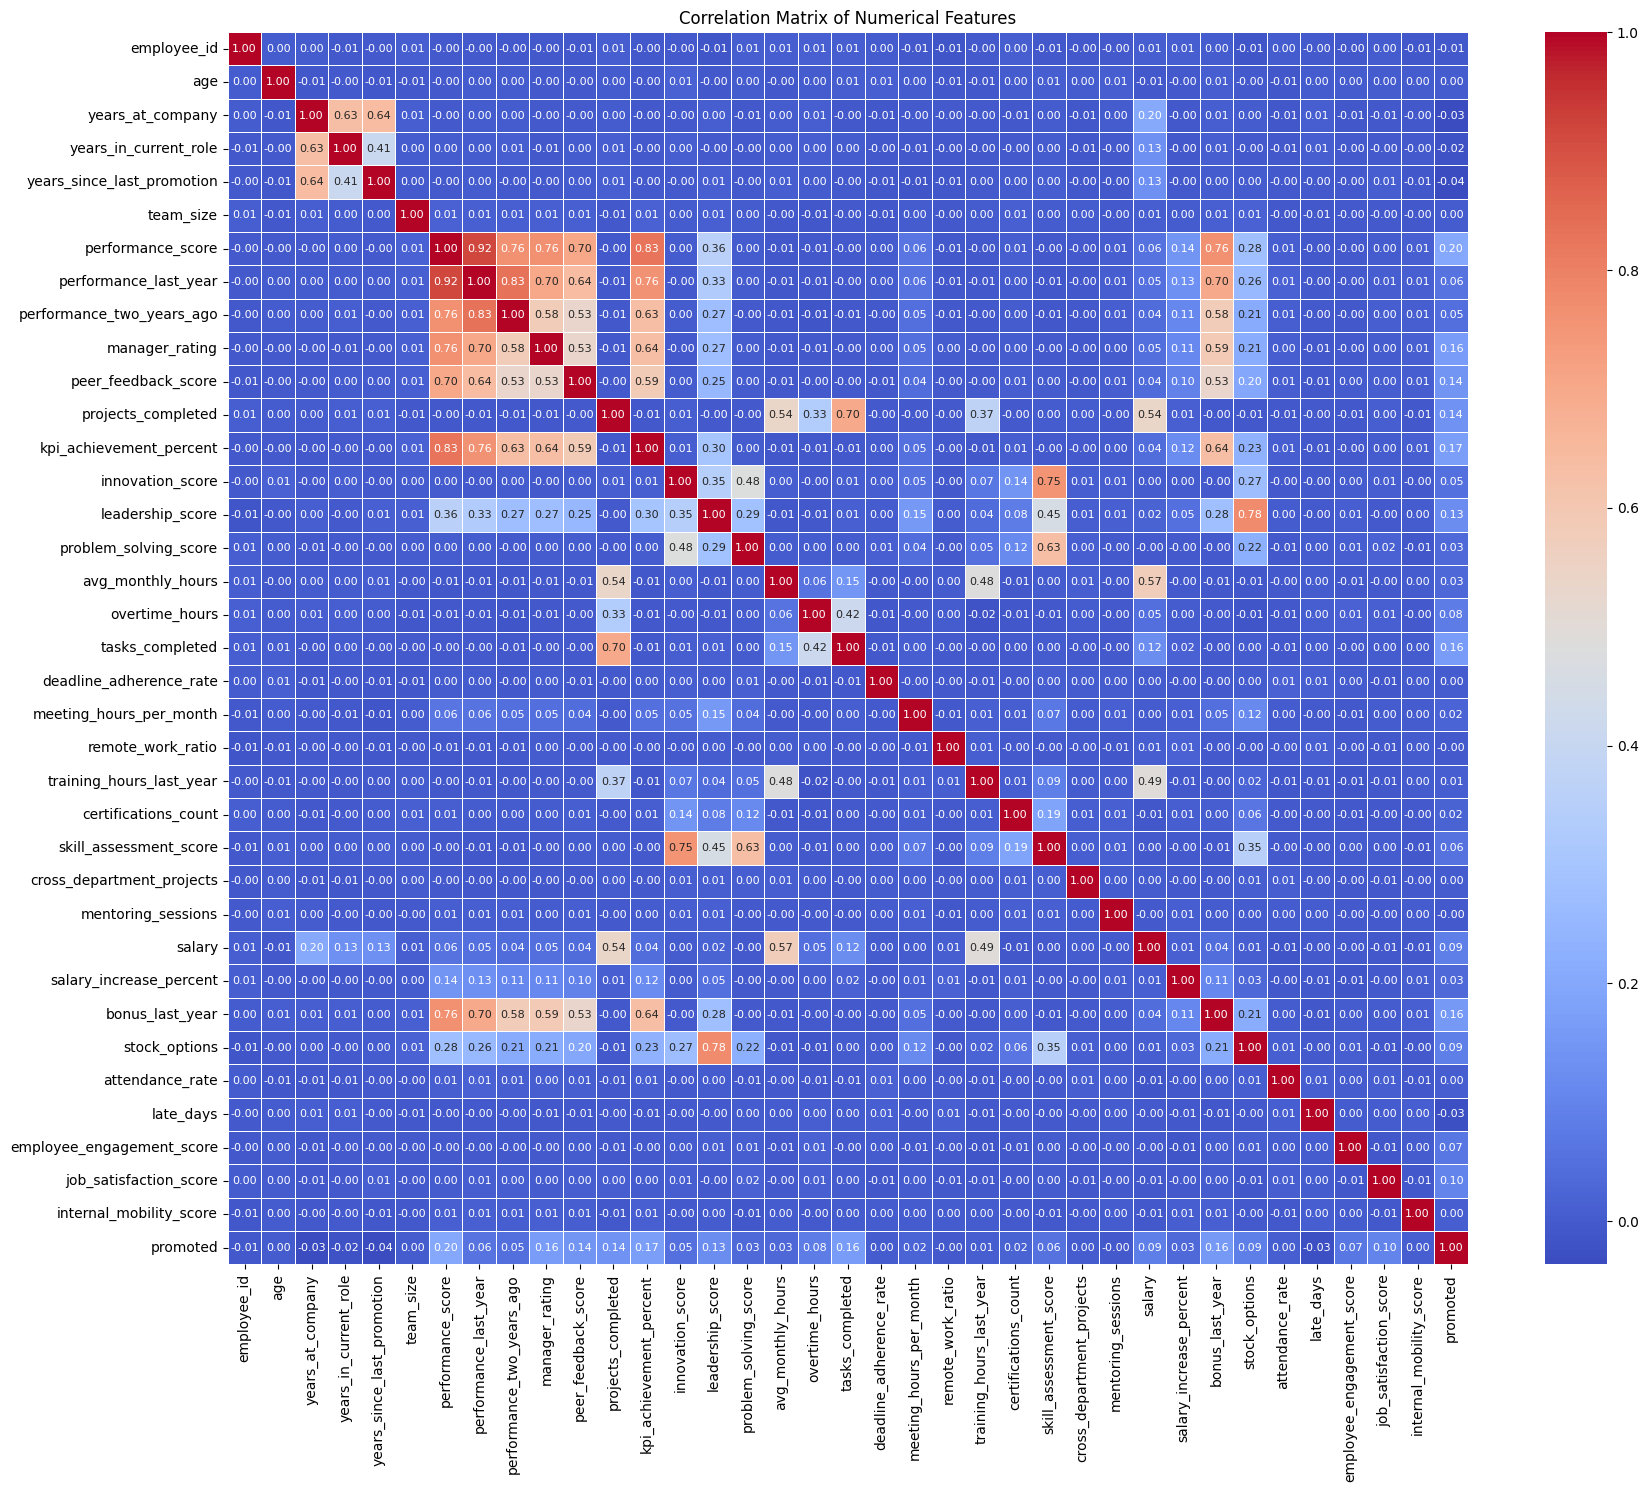

In [6]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8}) # Set annot=True to show numbers
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Eliminar columnas que no aportan al modelo

Vamos a quitar las siguientes features de para reducir el ruido y la multicolianealidad:

'employee_id',
    'team_size',
    'remote_work_ratio',
    'deadline_adherence_rate',
    'cross_department_projects',
    'mentoring_sessions',
    'internal_mobility_score',
    'attendance_rate',
    'training_hours_last_year',
    'certifications_count',
    'performance_last_year',
    'performance_two_years_ago'



In [7]:
df = df.drop(columns=['employee_id',
    'team_size',
    'remote_work_ratio',
    'deadline_adherence_rate',
    'cross_department_projects',
    'mentoring_sessions',
    'internal_mobility_score',
    'attendance_rate',
    'training_hours_last_year',
    'certifications_count',
    'performance_last_year',
    'performance_two_years_ago'])

print("Nueva forma del dataset:", df.shape)

Nueva forma del dataset: (29853, 31)


In [8]:
X = df.drop(columns=['promoted'])
y = df['promoted']

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (29853, 30)
Shape de y: (29853,)


## Separar entrenamiento, validación y prueba

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nDistribución en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en y_val:")
print(y_val.value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (23882, 30)
X_val  : (2985, 30)
X_test : (2986, 30)
y_train: (23882,)
y_val  : (2985,)
y_test : (2986,)

Distribución en y_train:
promoted
0    89.891969
1    10.108031
Name: proportion, dtype: float64

Distribución en y_val:
promoted
0    89.916248
1    10.083752
Name: proportion, dtype: float64

Distribución en y_test:
promoted
0    89.886135
1    10.113865
Name: proportion, dtype: float64


## Identificar columnas numéricas y categóricas

In [10]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Columnas numéricas:", numeric_features)
print("\nColumnas categóricas:", categorical_features)

Columnas numéricas: ['age', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'performance_score', 'manager_rating', 'peer_feedback_score', 'projects_completed', 'kpi_achievement_percent', 'innovation_score', 'leadership_score', 'problem_solving_score', 'avg_monthly_hours', 'overtime_hours', 'tasks_completed', 'meeting_hours_per_month', 'skill_assessment_score', 'salary', 'salary_increase_percent', 'bonus_last_year', 'stock_options', 'late_days', 'employee_engagement_score', 'job_satisfaction_score']

Columnas categóricas: ['gender', 'education_level', 'marital_status', 'city_tier', 'department', 'employment_type']


## Preprocesamiento

* numéricas: imputación por mediana + StandardScaler
* categóricas: imputación por moda + OneHotEncoder

In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Aplicar preprocesamiento a train y test

In [12]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Forma de X_train procesado:", X_train_processed.shape)
print("Forma de X_val procesado  :", X_val_processed.shape)
print("Forma de X_test procesado :", X_test_processed.shape)

Forma de X_train procesado: (23882, 43)
Forma de X_val procesado  : (2985, 43)
Forma de X_test procesado : (2986, 43)


## Aplicar SMOTE solo al conjunto de entrenamiento

Ya que el set de datos esta desvalancedo teniendo 90% instancias sin promoción y el otro 10% con. Usamos la tecnica de SMOTE para balancear el dataset

In [13]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("Antes de SMOTE:")
print(y_train.value_counts())

print("\nDespués de SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

print("\nForma de X_train después de SMOTE:", X_train_resampled.shape)
print("Forma de y_train después de SMOTE:", y_train_resampled.shape)

print("Distribución original de y_train (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución balanceada de y_train_resampled (%):")
print(pd.Series(y_train_resampled).value_counts(normalize=True) * 100)

Antes de SMOTE:
promoted
0    21468
1     2414
Name: count, dtype: int64

Después de SMOTE:
promoted
0    21468
1    21468
Name: count, dtype: int64

Forma de X_train después de SMOTE: (42936, 43)
Forma de y_train después de SMOTE: (42936,)
Distribución original de y_train (%):
promoted
0    89.891969
1    10.108031
Name: proportion, dtype: float64

Distribución balanceada de y_train_resampled (%):
promoted
0    50.0
1    50.0
Name: proportion, dtype: float64


## Entrenar modelo Random Forest

Aquí usamos Random Forest como modelo de clasificación para predecir promoted.

* Es un modelo de ensamble
basado en múltiples árboles.
* Ayuda a mejorar la capacidad de generalización y a reducir sobreajuste frente a un solo árbol.

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [15]:
y_train_pred = rf_model.predict(X_train_resampled)
y_val_pred = rf_model.predict(X_val_processed)
y_test_pred = rf_model.predict(X_test_processed)

y_train_proba = rf_model.predict_proba(X_train_resampled)[:, 1]
y_val_proba = rf_model.predict_proba(X_val_processed)[:, 1]
y_test_proba = rf_model.predict_proba(X_test_processed)[:, 1]

## Calcular las metricas

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluar_modelo(y_true, y_pred, y_proba, nombre_conjunto="Conjunto"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    print(f"--- {nombre_conjunto} ---")
    print(f"Accuracy     : {acc:.4f}")
    print(f"Precision    : {prec:.4f}")
    print(f"Recall       : {rec:.4f}")
    print(f"F1-score     : {f1:.4f}")
    print(f"ROC-AUC      : {roc_auc:.4f}")
    print(f"PR-AUC       : {pr_auc:.4f}")
    print()

evaluar_modelo(y_train_resampled, y_train_pred, y_train_proba, "Train")
evaluar_modelo(y_val, y_val_pred, y_val_proba, "Validation")
evaluar_modelo(y_test, y_test_pred, y_test_proba, "Test")

--- Train ---
Accuracy     : 0.9192
Precision    : 0.9146
Recall       : 0.9249
F1-score     : 0.9197
ROC-AUC      : 0.9735
PR-AUC       : 0.9722

--- Validation ---
Accuracy     : 0.8626
Precision    : 0.3741
Recall       : 0.5382
F1-score     : 0.4414
ROC-AUC      : 0.8425
PR-AUC       : 0.3930

--- Test ---
Accuracy     : 0.8620
Precision    : 0.3703
Recall       : 0.5199
F1-score     : 0.4325
ROC-AUC      : 0.8265
PR-AUC       : 0.4049



## Reporte de clasificación

In [17]:
from sklearn.metrics import classification_report

print("--- Classification Report: Validation ---")
print(classification_report(y_val, y_val_pred))

print("\n--- Classification Report: Test ---")
print(classification_report(y_test, y_test_pred))

--- Classification Report: Validation ---
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2684
           1       0.37      0.54      0.44       301

    accuracy                           0.86      2985
   macro avg       0.66      0.72      0.68      2985
weighted avg       0.89      0.86      0.87      2985


--- Classification Report: Test ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2684
           1       0.37      0.52      0.43       302

    accuracy                           0.86      2986
   macro avg       0.66      0.71      0.68      2986
weighted avg       0.89      0.86      0.87      2986



## Matriz de confución

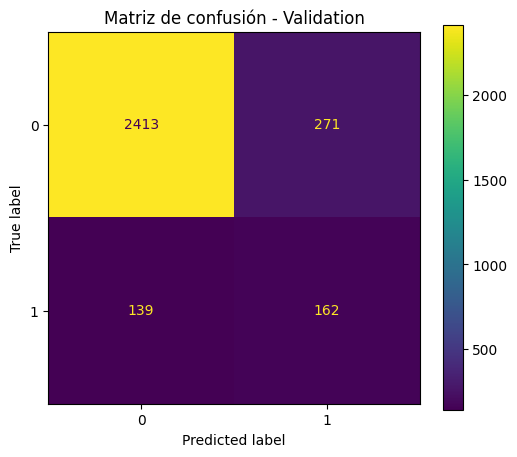

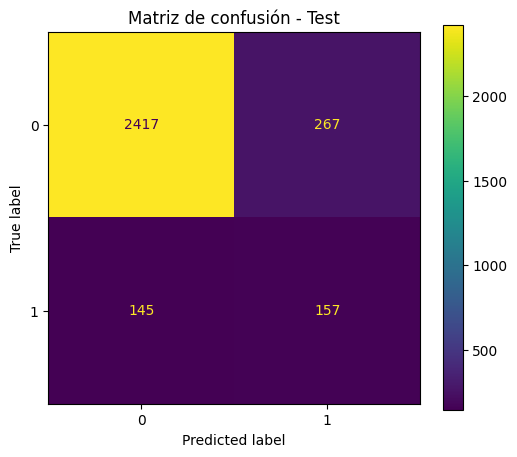

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(ax=ax)
plt.title("Matriz de confusión - Validation")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(ax=ax)
plt.title("Matriz de confusión - Test")
plt.show()